# FTCircuitBench Pipeline Walkthrough

This notebook walks through FTCircuitBench's full compilation and analysis
pipeline on one benchmark circuit:

```
 QASM input  →  Clifford+T synthesis  →  analysis + plots
                (Gridsynth)
             →  Pauli-based computation  →  analysis + plots
                (PBC conversion)
```

Along the way it produces the statistics and figures FTCircuitBench reports for
every circuit in the benchmark suite: T counts, interaction graphs, T-gate
density, PBC operator structure, and Pauli-weight distributions.

**Runtime.** The default input is a 100-qubit Heisenberg Hamiltonian simulation
circuit compiled at Gridsynth precision 8 — a realistic workload that produces
~2.9 million T gates. End to end it takes **about 45 minutes** (most of it in
the PBC conversion). For a quick pass, point `qasm_file` at a smaller circuit
such as `qasm/qft/qft_18q.qasm`, which runs in seconds.

**Setup** (one time, from the repository root):

```bash
uv sync --all-extras
```

then select the project `.venv` kernel. For the shorter, end-to-end resource
estimation story — Qualtran → FTCircuitBench → Azure QRE — see the companion
notebook [`Qualtran_to_QRE_Demo.ipynb`](Qualtran_to_QRE_Demo.ipynb) in this
folder.

## Setup

Imports, a working-directory shim so relative paths behave regardless of where
the notebook is launched, and a check of which synthesis backend is active
(the `nwqec` C++ backend when available, Python Gridsynth otherwise).

In [15]:
# Standard imports
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
from collections import defaultdict

# Resolve the repo root so relative paths (qasm/, figs/) work no matter
# where the notebook is launched from (repo root, demos/, an IDE, ...).

def _find_repo_root(start: Path) -> Path:
    cur = start
    for _ in range(10):
        if (cur / "ftcircuitbench").is_dir() or (cur / "pyproject.toml").is_file():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start

cwd = Path.cwd().resolve()
repo_root = _find_repo_root(cwd)

# Make relative paths (e.g. qasm/...) work regardless of notebook launch dir
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPO_ROOT = repo_root

# Add cabal bin to PATH for gridsynth
os.environ["PATH"] = (
    os.path.expanduser("~/.cabal/bin") + ":" + os.environ.get("PATH", "")
)

# Import FTCircuitBench components
from ftcircuitbench import (
    load_qasm_circuit,
    show_operator_weight_histogram,
    show_qubit_pbc_operations_plot,
    convert_to_pbc_circuit,
)
from ftcircuitbench.analyzer import analyze_clifford_t_circuit, analyze_pbc_circuit
from ftcircuitbench.analyzer.visualization import (
    show_clifford_t_interaction_graph,
    plot_clifford_t_tgate_heatmap,
    plot_pbc_operator_heatmap,
    show_pbc_interaction_graph,
    plot_pbc_pauli_weight_binned_bands,
)

# transpile_to_gridsynth_clifford_t prefers nwqec C++ when available.
from ftcircuitbench.transpilers import (
    is_nwqec_available,
    transpile_to_gridsynth_clifford_t,
    transpile_to_solovay_kitaev_clifford_t
)

# Confirm nwqec is importable + whether C++ gridsynth is enabled
try:
    import nwqec

    print(f"nwqec importable: True (version={getattr(nwqec, '__version__', 'unknown')})")
    print(f"nwqec.WITH_GRIDSYNTH_CPP: {getattr(nwqec, 'WITH_GRIDSYNTH_CPP', None)}")
except Exception as e:
    nwqec = None
    print(f"nwqec importable: False ({e})")

print(f"ftcircuitbench.transpilers.is_nwqec_available(): {is_nwqec_available()}")

# Set up matplotlib for better plots
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

nwqec importable: True (version=0.1.1)
nwqec.WITH_GRIDSYNTH_CPP: True
ftcircuitbench.transpilers.is_nwqec_available(): True


## Step 1 — Load a benchmark circuit

Any OpenQASM 2/3 file works. The gate distribution below is the *logical*
input: mostly `rz` rotations and CNOTs, not yet executable on error-corrected
hardware.

In [16]:
# Load a circuit
qasm_file = "qasm/hamiltonians/heisenberg_2d_triangular_100q.qasm"

title = qasm_file.split("/")[-1].split(".")[0]
print(f"📁 Loading circuit from: {qasm_file}")

original_circuit = load_qasm_circuit(qasm_file, is_file=True)

print("✅ Circuit loaded successfully!")
print(f"   - Number of qubits: {original_circuit.num_qubits}")
print(f"   - Number of gates: {len(original_circuit.data)}")
print(f"   - Circuit depth: {original_circuit.depth()}")

# Display circuit information
gate_counts = defaultdict(int)
for instruction in original_circuit.data:
    gate_name = instruction.operation.name
    gate_counts[gate_name] += 1

print("   - Gate distribution:")
for gate, count in sorted(gate_counts.items()):
    print(f"     * {gate}: {count}")

📁 Loading circuit from: qasm/hamiltonians/heisenberg_2d_triangular_100q.qasm
✅ Circuit loaded successfully!
   - Number of qubits: 100
   - Number of gates: 1259780
   - Circuit depth: 579380
   - Gate distribution:
     * cx: 71960
     * h: 263960
     * rz: 923860


## Step 2 — Transpile to Clifford+T

Fault-tolerant hardware runs a discrete gate set, so every `rz` rotation must
be synthesised into Clifford gates plus T gates. FTCircuitBench uses
**Gridsynth** (here at precision 8, i.e. ~10⁻⁸ synthesis error per rotation);
the commented-out block shows the **Solovay-Kitaev** alternative. The
`intermediate_circuit` is the canonical Clifford+RZ staging both pipelines
share.

In [17]:
print("🔄 Transpiling to Clifford+T basis...")

start_time = time.time()

# gridsynth decomposition
intermediate_circuit, clifford_t_circuit = transpile_to_gridsynth_clifford_t(
    original_circuit.copy(), 
    gridsynth_precision=8, 
    return_intermediate=True
)

# solovay kitaev decomposition
# intermediate_circuit, clifford_t_circuit = transpile_to_solovay_kitaev_clifford_t(
#     original_circuit.copy(), 
#     recursion_degree=3,
#     return_intermediate=True
# )

transpilation_time = time.time() - start_time

print(f"✅ Transpilation completed in {transpilation_time:.3f} seconds!")
print(f"   - Original gates: {len(original_circuit.data)}")
print(f"   - Clifford+T gates: {len(clifford_t_circuit.data)}")
print(f"   - Circuit depth: {clifford_t_circuit.depth()}")

# Analyze gate distribution
gate_counts = defaultdict(int)
for instruction in clifford_t_circuit.data:
    gate_name = instruction.operation.name
    gate_counts[gate_name] += 1

print("   - Clifford+T gate distribution:")
for gate, count in sorted(gate_counts.items()):
    print(f"     * {gate}: {count}")

# Count RZ gates in intermediate circuit
rz_count = sum(
    1
    for instruction in intermediate_circuit.data
    if instruction.operation.name == "rz"
)
print(f"   - RZ gates in intermediate circuit: {rz_count}")

🔄 Transpiling to Clifford+T basis...
✅ Transpilation completed in 28.071 seconds!
   - Original gates: 1259780
   - Clifford+T gates: 8091700
   - Circuit depth: 5447062
   - Clifford+T gate distribution:
     * cx: 71960
     * h: 3178300
     * s: 1306960
     * sdg: 467960
     * t: 2902360
     * z: 164160
   - RZ gates in intermediate circuit: 923860


## Step 3 — Analyze the Clifford+T circuit

`analyze_clifford_t_circuit` reports gate counts and qubit-interaction
statistics. The **T-family count** is the headline number: on error-corrected
hardware, Clifford gates are cheap and each T gate must be distilled by a
T factory.

In [18]:
print("🔍 Analyzing Clifford+T circuit...")

clifford_t_stats = analyze_clifford_t_circuit(clifford_t_circuit)

print("✅ Analysis completed!")
print(f"   - T gates: {clifford_t_stats.get('t_count', 0)}")
print(f"   - T† gates: {clifford_t_stats.get('tdg_count', 0)}")
print(
    f"   - Total T-family gates: {clifford_t_stats.get('total_t_family_count', 0)}"
)
print(f"   - Clifford gates: {clifford_t_stats.get('clifford_gate_count', 0)}")
print(f"   - Total gates: {clifford_t_stats.get('total_gate_count', 0)}")
print(f"   - Circuit depth: {clifford_t_stats.get('depth', 0)}")
print(f"   - Two-qubit gates: {clifford_t_stats.get('total_two_qubit_gates', 0)}")

# Display interaction statistics
if "interaction_graph_density" in clifford_t_stats:
    density = clifford_t_stats["interaction_graph_density"]
    if isinstance(density, (int, float)):
        print(f"   - Interaction graph density: {density:.3f}")
    else:
        print(f"   - Interaction graph density: {density}")

if "qubit_interaction_degree" in clifford_t_stats:
    degrees = clifford_t_stats["qubit_interaction_degree"]
    print(f"   - Qubit interaction degrees: {degrees}")

🔍 Analyzing Clifford+T circuit...
✅ Analysis completed!
   - T gates: 2902360
   - T† gates: 0
   - Total T-family gates: 2902360
   - Clifford gates: 5189340
   - Total gates: 8091700
   - Circuit depth: 5447062
   - Two-qubit gates: 71960
   - Interaction graph density: 14.537
   - Qubit interaction degrees: {0: 1400, 1: 1440, 2: 1440, 3: 1440, 4: 1440, 5: 1440, 6: 1440, 7: 1440, 8: 1440, 9: 1440, 10: 1440, 11: 1440, 12: 1440, 13: 1440, 14: 1440, 15: 1440, 16: 1440, 17: 1440, 18: 1440, 19: 1440, 20: 1440, 21: 1440, 22: 1440, 23: 1440, 24: 1440, 25: 1440, 26: 1440, 27: 1440, 28: 1440, 29: 1440, 30: 1440, 31: 1440, 32: 1440, 33: 1440, 34: 1440, 35: 1440, 36: 1440, 37: 1440, 38: 1440, 39: 1440, 40: 1440, 41: 1440, 42: 1440, 43: 1440, 44: 1440, 45: 1440, 46: 1440, 47: 1440, 48: 1440, 49: 1440, 50: 1440, 51: 1440, 52: 1440, 53: 1440, 54: 1440, 55: 1440, 56: 1440, 57: 1440, 58: 1440, 59: 1440, 60: 1440, 61: 1440, 62: 1440, 63: 1440, 64: 1440, 65: 1440, 66: 1440, 67: 1440, 68: 1440, 69: 144

### Interaction graph

Which qubits talk to which, weighted by how often. Community structure and
degree distribution here indicate how much routing pressure the circuit puts on
a physical layout.

📊 Creating interaction graph visualization...
📄 Plot saved as: figs/heisenberg_2d_triangular_100q_clifford_t_interaction_graph_interaction_graph.pdf


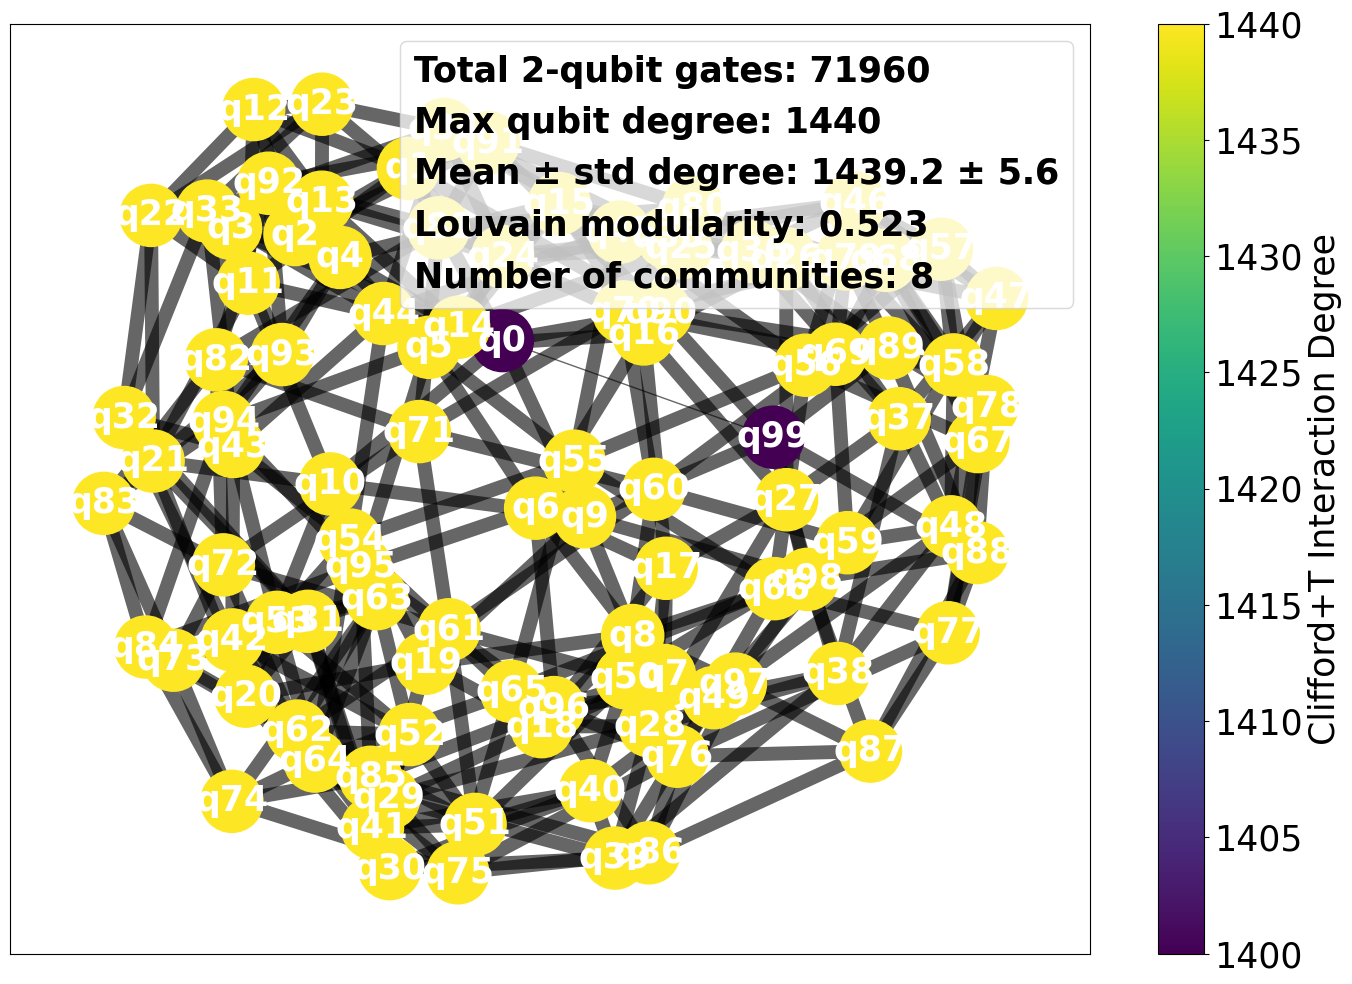

✅ Clifford+T Interaction graph created!
   - Total 2-qubit gates: 71960
   - Qubit interaction degrees: {0: 1400, 1: 1440, 2: 1440, 3: 1440, 4: 1440, 5: 1440, 6: 1440, 7: 1440, 8: 1440, 9: 1440, 10: 1440, 11: 1440, 12: 1440, 13: 1440, 14: 1440, 15: 1440, 16: 1440, 17: 1440, 18: 1440, 19: 1440, 20: 1440, 21: 1440, 22: 1440, 23: 1440, 24: 1440, 25: 1440, 26: 1440, 27: 1440, 28: 1440, 29: 1440, 30: 1440, 31: 1440, 32: 1440, 33: 1440, 34: 1440, 35: 1440, 36: 1440, 37: 1440, 38: 1440, 39: 1440, 40: 1440, 41: 1440, 42: 1440, 43: 1440, 44: 1440, 45: 1440, 46: 1440, 47: 1440, 48: 1440, 49: 1440, 50: 1440, 51: 1440, 52: 1440, 53: 1440, 54: 1440, 55: 1440, 56: 1440, 57: 1440, 58: 1440, 59: 1440, 60: 1440, 61: 1440, 62: 1440, 63: 1440, 64: 1440, 65: 1440, 66: 1440, 67: 1440, 68: 1440, 69: 1440, 70: 1440, 71: 1440, 72: 1440, 73: 1440, 74: 1440, 75: 1440, 76: 1440, 77: 1440, 78: 1440, 79: 1440, 80: 1440, 81: 1440, 82: 1440, 83: 1440, 84: 1440, 85: 1440, 86: 1440, 87: 1440, 88: 1440, 89: 1440, 90: 1

In [19]:
print("📊 Creating interaction graph visualization...")

# Use the new native function
show_clifford_t_interaction_graph(
    clifford_t_circuit,
    name=f"{title}_clifford_t_interaction_graph",
    node_size=2000,
)

### T-gate density heatmap

Where the T gates fall, per qubit over the course of the circuit — a view of
how evenly the distillation workload is spread in space and time.

📄 Plot saved as: figs/heisenberg_2d_triangular_100q_t_density_tgate_heatmap.pdf


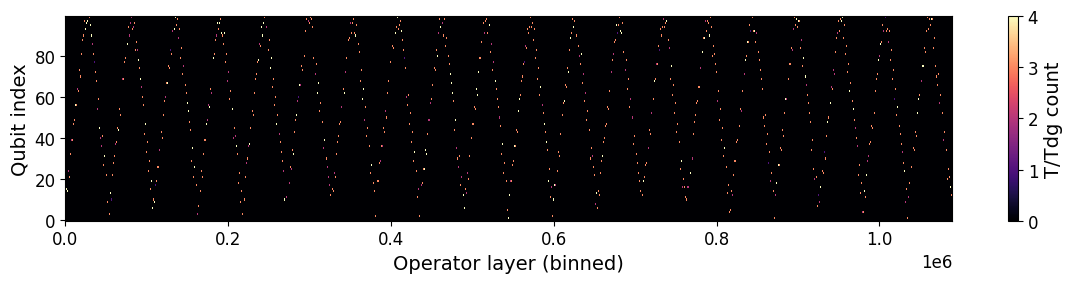

✅ Saved T-gate heatmap for 'heisenberg_2d_triangular_100q_t_density'. Bins: 1089412, Layers: 8091700


In [20]:
plot_clifford_t_tgate_heatmap(clifford_t_circuit,
                              use_layers=False,
                              name =f"{title}_t_density",
                              time_bins=clifford_t_circuit.depth()/5
                              )

## Step 4 — Convert to Pauli-based computation

PBC re-expresses the Clifford+T circuit as a sequence of multi-qubit **Pauli
rotations** followed by Pauli **measurements** — the form in which a
surface-code machine executes it, with Cliffords absorbed rather than executed.
This is the long step on large circuits.

In [21]:
print("🔄 Converting to PBC...")

start_time = time.time()

# Use the existing convert_to_pbc_circuit function directly
pbc_circuit, pbc_stats = convert_to_pbc_circuit(clifford_t_circuit, optimize_pbc=False)

conversion_time = time.time() - start_time

print(f"✅ PBC conversion completed in {conversion_time:.3f} seconds")
print(f"   - PBC circuit layers: {pbc_circuit.depth()}")
print(f"   - Total PBC gates: {len(pbc_circuit.data)}") #including barriers

🔄 Converting to PBC...
✅ PBC conversion completed in 2343.396 seconds
   - PBC circuit layers: 2902460
   - Total PBC gates: 5788980


## Step 5 — Analyze the PBC circuit

The unit of cost changes: instead of gates, count **Pauli operators** and their
**weight** (how many qubits each acts on). Weight determines how expensive each
lattice-surgery operation is to perform.

In [22]:
# Analyze PBC circuit
pbc_analysis = analyze_pbc_circuit(pbc_circuit, pbc_stats)

print(f"   - T operators: {pbc_analysis.get('pbc_t_operators', 0)}")
print(
    f"   - Measurement operators: {pbc_analysis.get('pbc_measurement_operators', 0)}"
)

# Display Pauli weight statistics
if "pbc_avg_pauli_weight" in pbc_analysis:
    avg_weight = pbc_analysis["pbc_avg_pauli_weight"]
    std_weight = pbc_analysis["pbc_std_pauli_weight"]
    if isinstance(avg_weight, (int, float)):
        print(f"   - Average Pauli weight: {avg_weight:.2f} ± {std_weight:.2f}")

print("\n📋 PBC Circuit Summary:")
print(f"Number of layers: {pbc_circuit.depth()}")
print(f"Total gates: {len(pbc_circuit.data)}")

   - T operators: 2902360
   - Measurement operators: 100
   - Average Pauli weight: 73.51 ± 9.22

📋 PBC Circuit Summary:
Number of layers: 2902460
Total gates: 5788980


### PBC interaction graph

The interaction structure after conversion. Absorbing Cliffords into the Pauli
frame typically densifies the graph relative to Step 3 — cost has moved from
gate count into operator weight.

📊 Creating interaction graph visualization...
📄 Plot saved as: figs/heisenberg_2d_triangular_100q_PBC_Interaction_Graph_pbc_interaction_graph.pdf


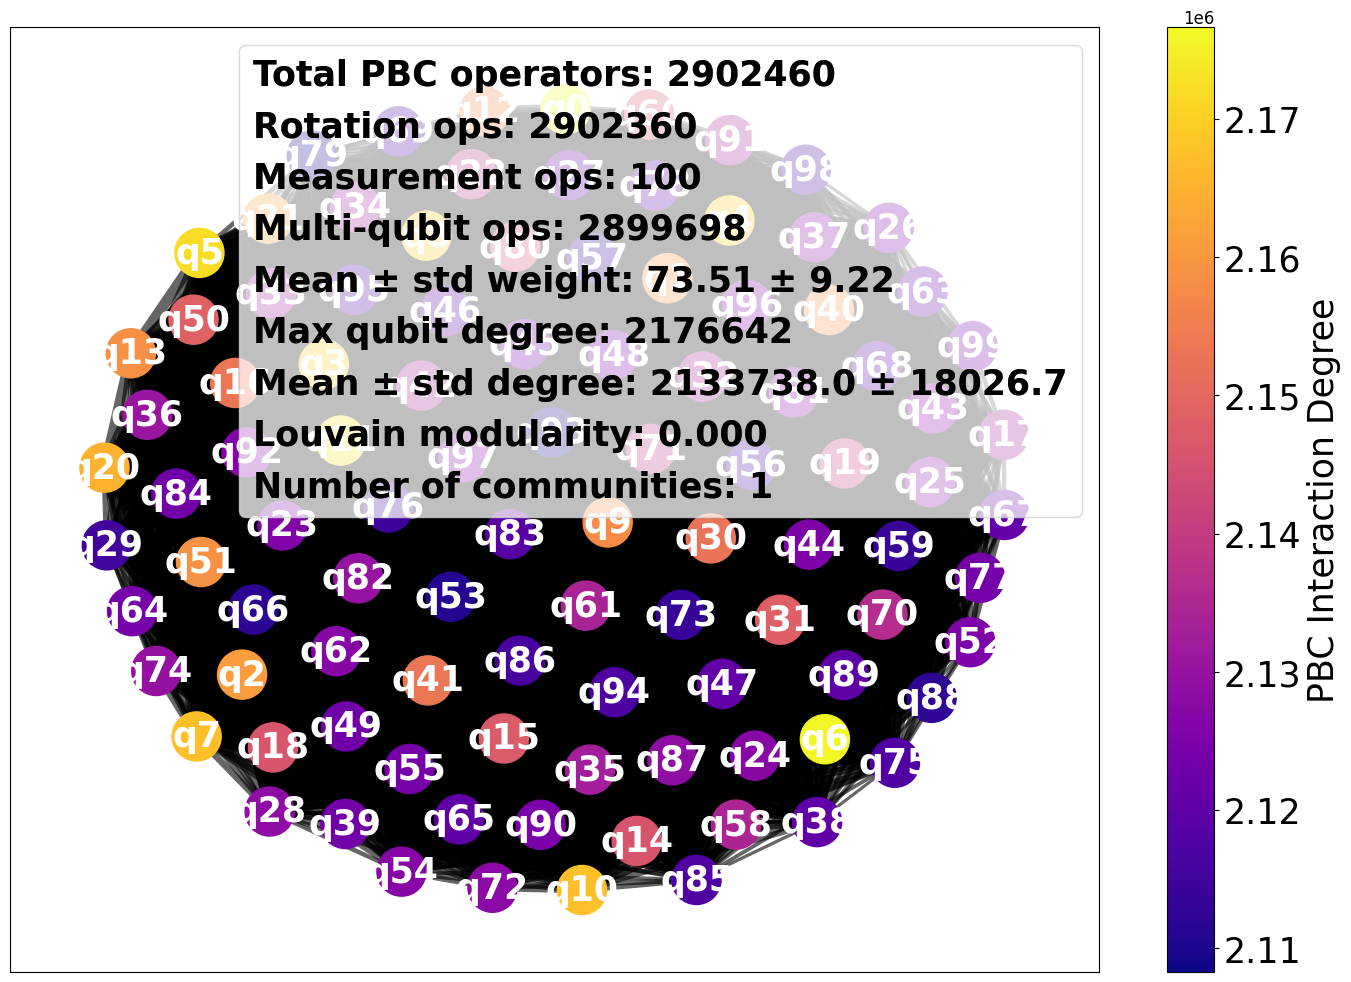

✅ PBC Interaction graph created!
   - Total PBC operators: 2902460 (rot: 2902360, meas: 100)
   - Multi-qubit ops: 2899698
   - Mean weight: 73.51 ± 9.22


In [23]:
print("📊 Creating interaction graph visualization...")

show_pbc_interaction_graph(
    pbc_circuit,
    name =f" {title} PBC Interaction Graph"
)

### Operator heatmap

Every PBC operator (row) against every qubit (column): the support pattern of
the whole computation at a glance.

📄 Plot saved as: figs/heisenberg_2d_triangular_100q_PBC_Operator_Heatmap_pbc_operator_heatmap.pdf


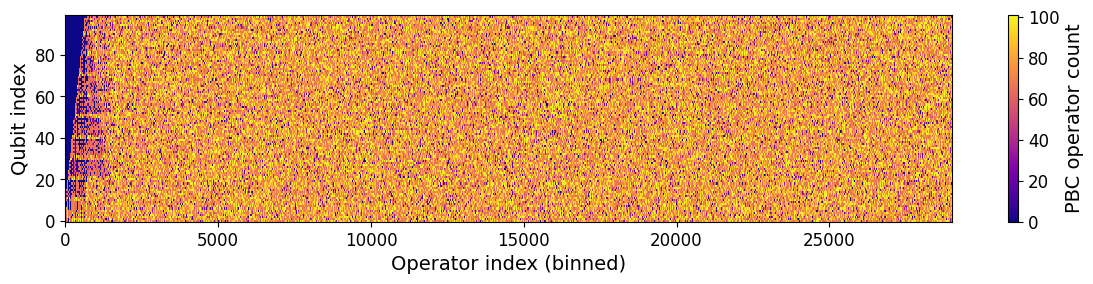

✅ Saved PBC operator heatmap for 'heisenberg_2d_triangular_100q PBC Operator Heatmap'. Bins: 29024, Operators: 2902460


In [24]:
plot_pbc_operator_heatmap(
    pbc_circuit,
    name =f"{title} PBC Operator Heatmap"
)

### Pauli weight over the computation

Operator weight as the computation proceeds (binned bands across the operator
sequence) — whether heavy operators cluster or spread out.

📄 Plot saved as: figs/heisenberg_2d_triangular_100q_PBC_Weight_vs_Index_pbc_weight_bands.pdf


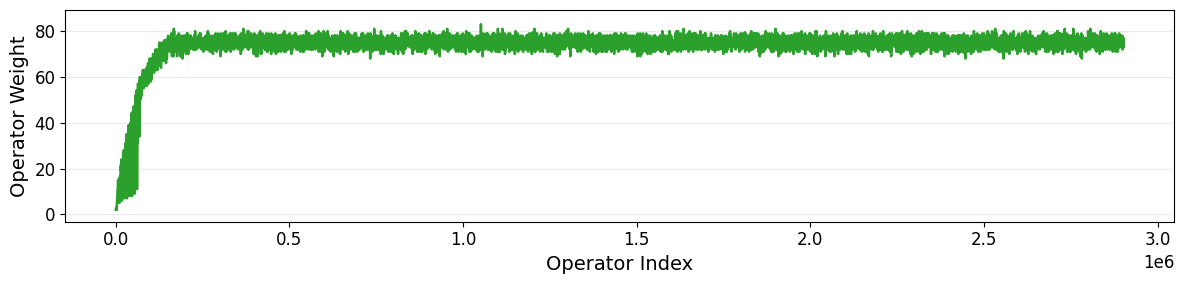

✅ Saved Pauli weight binned-bands plot for 'heisenberg_2d_triangular_100q PBC Weight vs Index'. Operators binned: 11577


In [25]:
plot_pbc_pauli_weight_binned_bands(pbc_circuit, bins=len(pbc_circuit.data)/500, name =f"{title} PBC Weight vs Index")

### Operator weight distribution

The histogram behind the average-weight statistic reported in Step 5.

📊 Creating operator weight histogram visualization...
📄 Plot saved as: figs/heisenberg_2d_triangular_100q_PBC_Operator_Weight_Distribution_pbc_operator_weight_histogram.pdf


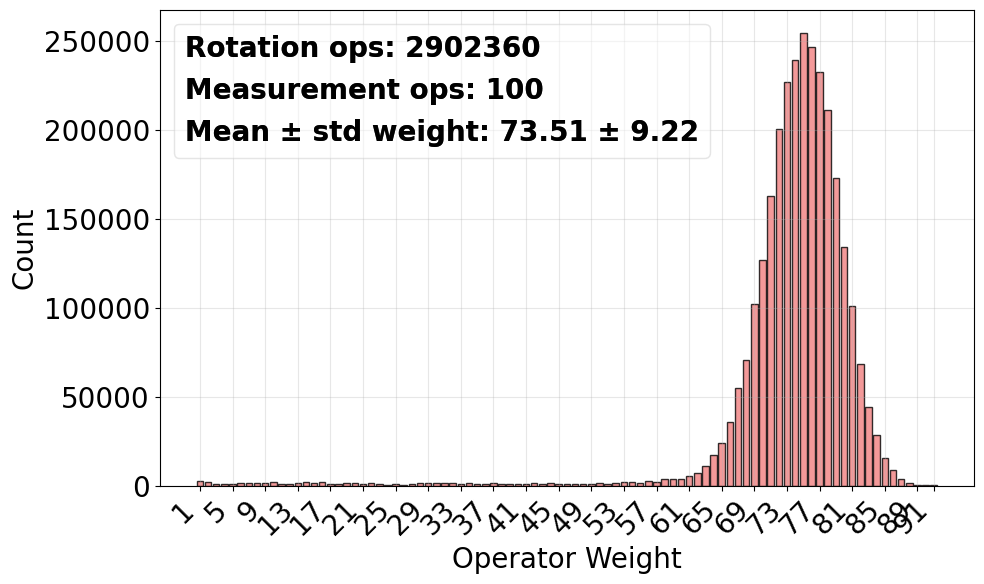

✅ PBC operator weight bar plot created!
   - Total PBC operators: 2902460
   - Rotation operators: 2902360
   - Measurement operators: 100
   - Weight range: 1 to 91
   - Mean weight: 73.51 ± 9.22


In [26]:
print("📊 Creating operator weight histogram visualization...")

# Use the new operator weight histogram function
show_operator_weight_histogram(
    pbc_circuit,
    name=f"{title} PBC Operator Weight Distribution"
)

### Operations per qubit

How many PBC rotations and measurements touch each qubit — the per-qubit view
of the workload.

📊 Creating qubit PBC operations plot visualization...
📄 Plot saved as: figs/heisenberg_2d_triangular_100q_PBC_Operations_per_Qubit_pbc_operations_per_qubit.pdf


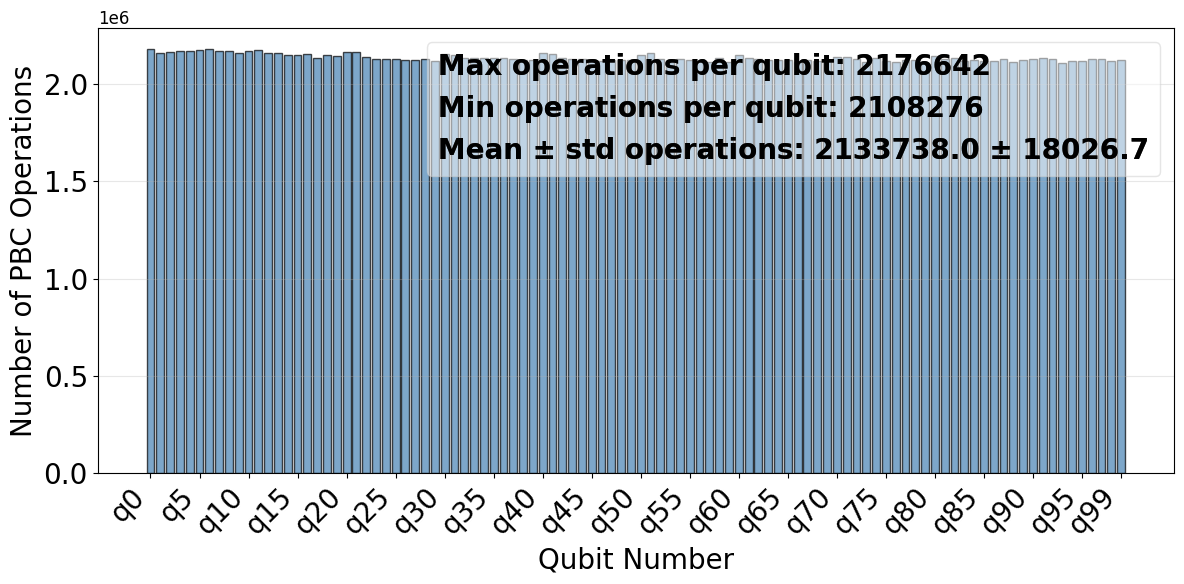

✅ PBC operations per qubit plot created!
   - Total PBC operations: 2902460
   - Total rotations: 2902360
   - Total measurements: 100
   - Active qubits: 100/100
   - Operations range: 2108276 to 2176642
   - Mean operations per qubit: 2133738.0 ± 18026.7


In [27]:
print("📊 Creating qubit PBC operations plot visualization...")

# Use the new qubit PBC operations plot function
show_qubit_pbc_operations_plot(
    pbc_circuit,
    name=f"{title} PBC Operations per Qubit"
)

## Summary

The pipeline in one table: original → Clifford+T → PBC, with the metrics that
carry forward to physical resource estimation. To take counts like these down
to physical qubits and runtime, see
[`Qualtran_to_QRE_Demo.ipynb`](Qualtran_to_QRE_Demo.ipynb) or the
`estimate_resources.py` CLI.

In [28]:
print("\n" + "=" * 80)
print(" FTCircuitBench Pipeline Summary")
print("=" * 80)

print(" Circuit Processing:")
print(
    f"   - Original circuit: {len(original_circuit.data)} gates, {original_circuit.num_qubits} qubits"
)
print(
    f"   - Clifford+T circuit: {len(clifford_t_circuit.data)} gates, {clifford_t_circuit.num_qubits} qubits"
)
print(
    f"   - PBC circuit: {len(pbc_circuit.data)} gates, {pbc_circuit.num_qubits} qubits"
)

print("\n Key Metrics:")
print(
    f"   - Gate expansion factor: {len(clifford_t_circuit.data) / len(original_circuit.data):.2f}x"
)
print(f"   - T-count: {clifford_t_stats.get('total_t_family_count', 0)}")
print(f"   - Circuit depth: {clifford_t_circuit.depth()}")

print("\n PBC Analysis:")
print(f"   - T operators: {pbc_analysis.get('pbc_t_operators', 0)}")
print(
    f"   - Measurement operators: {pbc_analysis.get('pbc_measurement_operators', 0)}"
)

if "pbc_avg_pauli_weight" in pbc_analysis:
    avg_weight = pbc_analysis["pbc_avg_pauli_weight"]
    print(f"   - Average Pauli weight: {avg_weight:.2f}")

print("\n FTCircuitBench pipeline completed successfully!")


 FTCircuitBench Pipeline Summary
 Circuit Processing:
   - Original circuit: 1259780 gates, 100 qubits
   - Clifford+T circuit: 8091700 gates, 100 qubits
   - PBC circuit: 5788980 gates, 100 qubits

 Key Metrics:
   - Gate expansion factor: 6.42x
   - T-count: 2902360
   - Circuit depth: 5447062

 PBC Analysis:
   - T operators: 2902360
   - Measurement operators: 100
   - Average Pauli weight: 73.51

 FTCircuitBench pipeline completed successfully!
